In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import libraryes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/drive/MyDrive/final project/Diseases_and_Symptoms_Data.csv')

# Data exploration

Explore the dataset to understand its structure and characteristics.


In [5]:
display(df.head())
print(df.shape,'\n')
print(df.info(),'\n')

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


(246945, 378) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB
None 



<ipython-input-21-dadd82f43a11>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.index, y=disease_counts, palette='viridis')


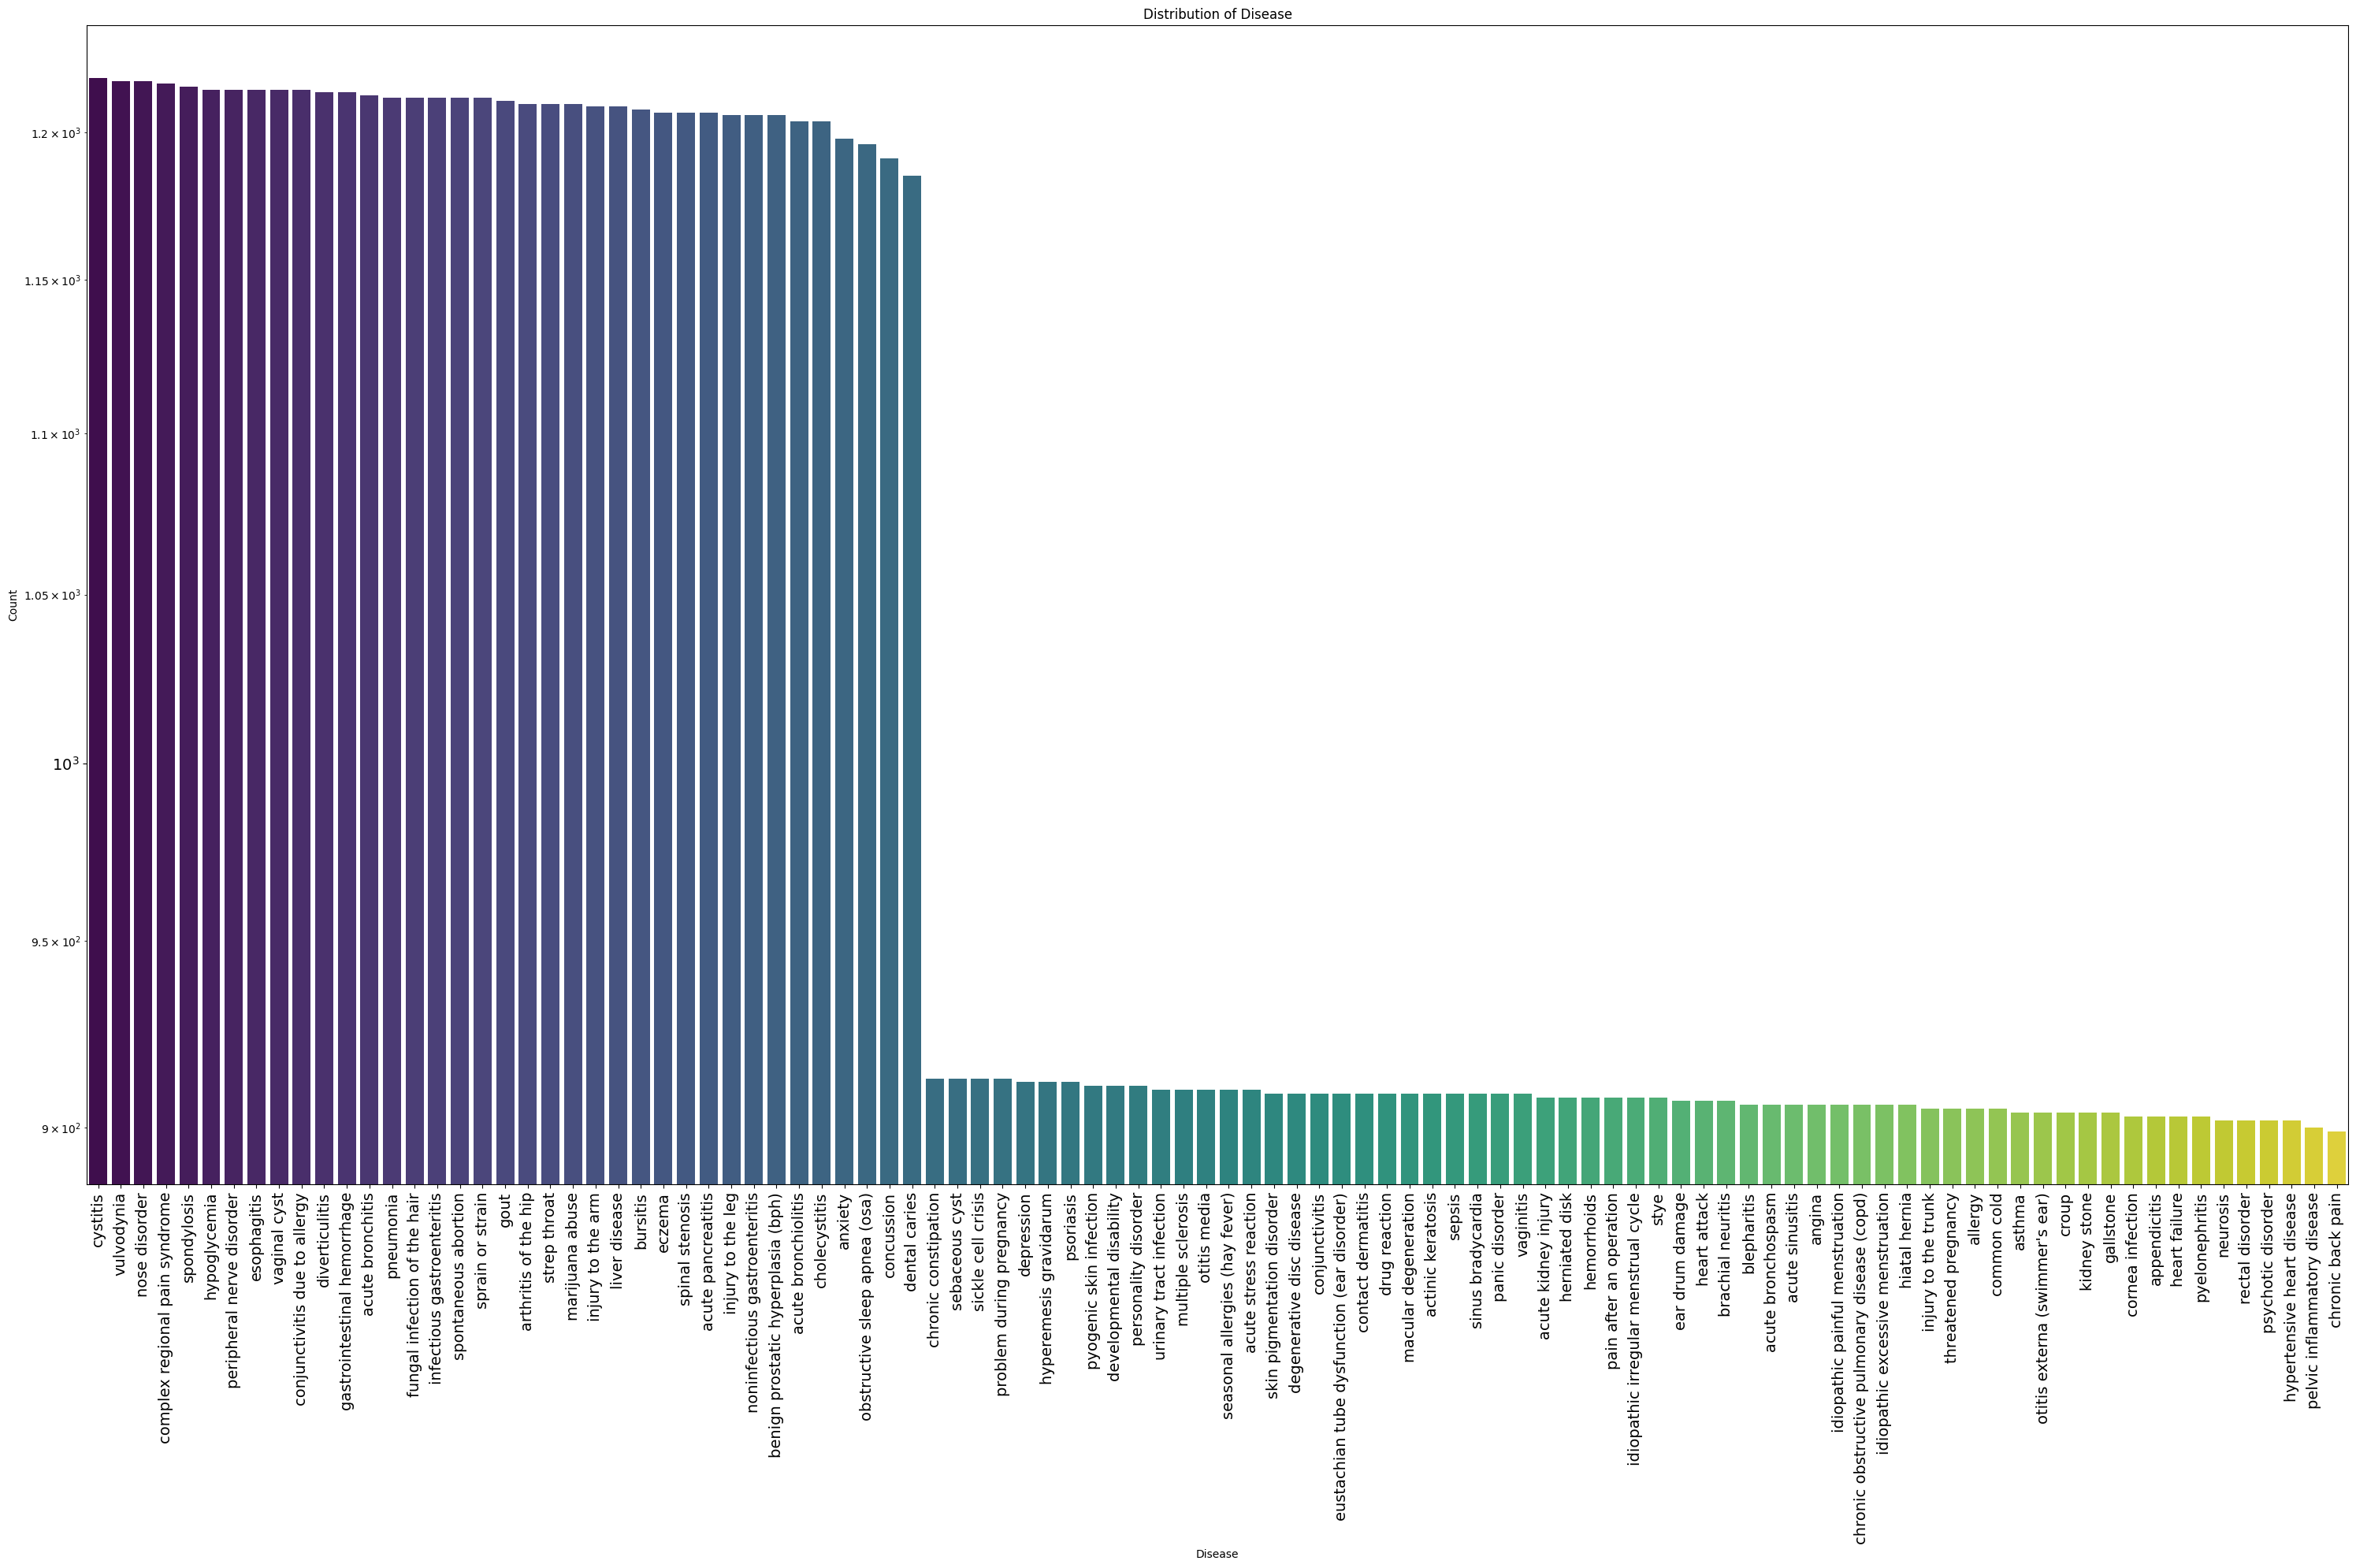

In [21]:
# analyze the distributionof disease
# get the top 100 most common disease
top_n = 100
disease_counts = df['diseases'].value_counts().head(top_n)
plt.figure(figsize=(30,20))
sns.barplot(x=disease_counts.index, y=disease_counts, palette='viridis')
# Increase font size)
plt.xticks(rotation=90, fontsize=14)
plt.yscale('log')
plt.yticks(fontsize=14)
plt.xlabel('Disease')
plt.ylabel('Count')
plt.title('Distribution of Disease')
plt.tight_layout()
plt.show()

In [39]:
# explore symptom distribution
symptom_columns = df.columns[1:]
descriptive_stats = df[symptom_columns].describe()
display(descriptive_stats)

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
count,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,246945.000000,...,246945.0,246945.0,246945.0,246945.0,246945.000000,246945.0,246945.0,246945.0,246945.000000,246945.0
mean,0.039235,0.042746,0.086440,0.061001,0.097252,0.069943,0.039410,0.040572,0.037871,0.024876,...,0.0,0.0,0.0,0.0,0.001385,0.0,0.0,0.0,0.000073,0.0
std,0.194155,0.202285,0.281014,0.239333,0.296302,0.255051,0.194568,0.197296,0.190884,0.155747,...,0.0,0.0,0.0,0.0,0.037189,0.0,0.0,0.0,0.008537,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,1.000000,0.0


In [40]:
# identify symptoms with unusual distributions (example : very high or low standard distribution)
symptom_std = df[symptom_columns].std()
mean_std = symptiom_std.mean()
std_std = symptiom_std.std()

# Identify symptoms with unusually high or low standard deviations
high_variability = symptom_std[symptom_std > mean_std + 2 * std_std]
low_variability = symptom_std[symptom_std < mean_std - 2 * std_std]

# Display results
print("Symptoms with High Variability:\n", high_variability)
print("\nSymptoms with Low Variability:\n", low_variability)


Symptoms with High Variability:
 shortness of breath                 0.281014
depressive or psychotic symptoms    0.239333
sharp chest pain                    0.296302
dizziness                           0.255051
cough                               0.297837
nasal congestion                    0.247585
skin swelling                       0.240082
leg pain                            0.247507
sharp abdominal pain                0.337211
vomiting                            0.316441
headache                            0.300133
nausea                              0.294482
lower abdominal pain                0.238380
abnormal appearing skin             0.249177
back pain                           0.283753
fever                               0.275255
dtype: float64

Symptoms with Low Variability:
 Series([], dtype: float64)


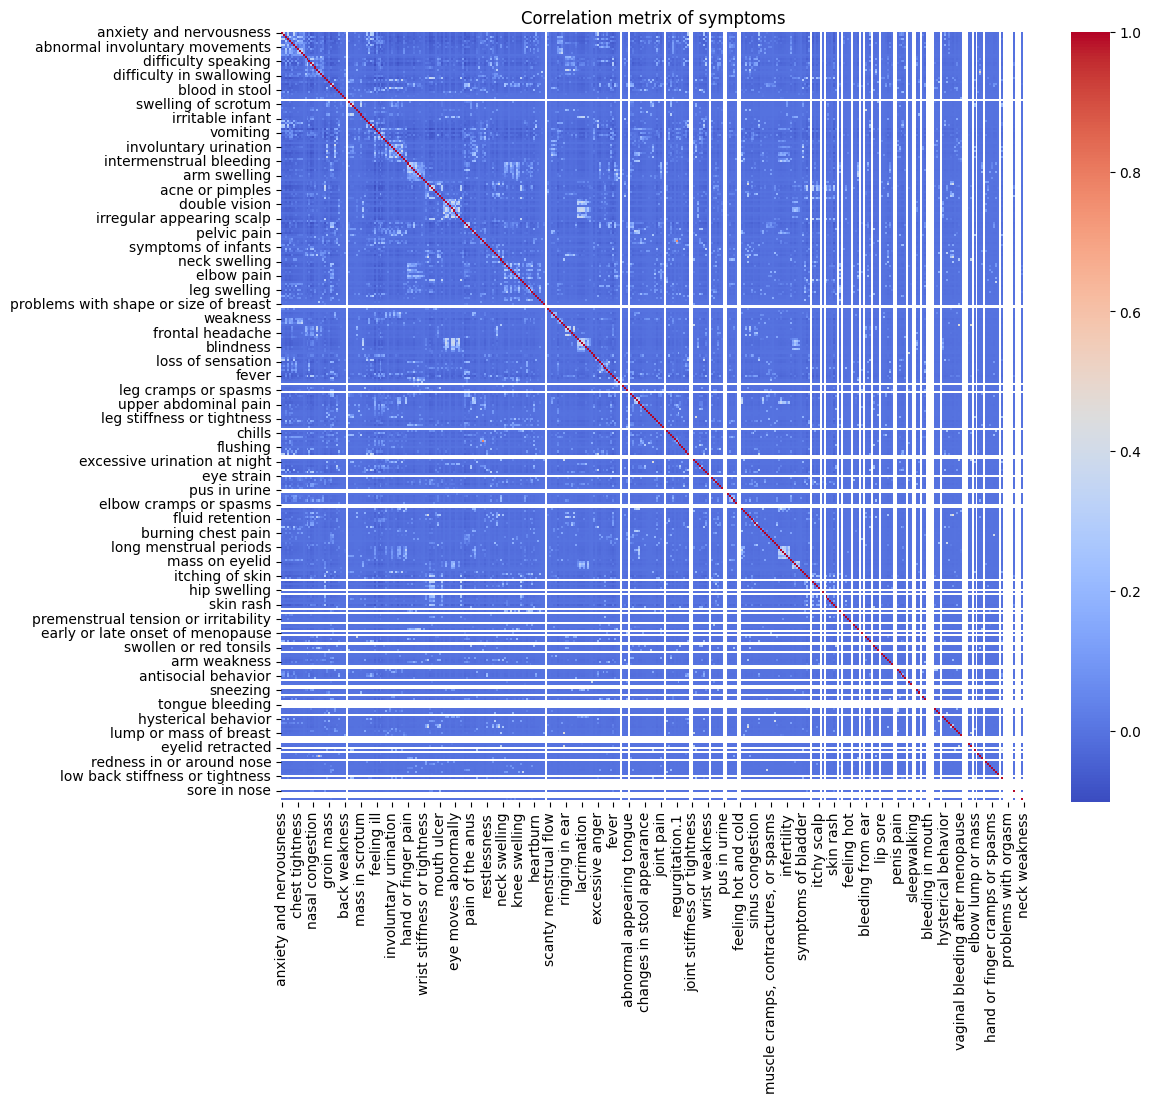

In [46]:
# assess potential correlations
plt.figure(figsize=(12,10))
sns.heatmap(df[symptom_columns].corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation metrix of symptoms')
plt.show()

## Data analysis

### Subtask:
Analyze the frequency of each disease and symptom, and identify potential relationships between them.


In [51]:
# calculate disease frequencies
disease_counts = df['diseases'].value_counts()
common_disease = disease_counts[disease_counts > 800]
rare_disease = disease_counts[disease_counts <= 800]

In [53]:
print(f'numbers of common disease: {len(common_disease)}')
print(f'numbers of rare disease: {len(rare_disease)}')

numbers of common disease: 114
numbers of rare disease: 659


In [55]:
print(f'common disease :\n{common_disease}\n')
print(f'rare disease :\n{rare_disease}')

common disease :
diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
fracture of the rib                882
pulmonary embolism                 880
seborrheic dermatitis              880
seborrheic keratosis               870
dry eye of unknown cause           861
Name: count, Length: 114, dtype: int64

rare disease :
diseases
bell palsy                      685
lipoma                          684
neuralgia                       684
gastroduodenal ulcer            683
urinary tract obstruction       683
                               ... 
typhoid fever                     1
rocky mountain spotted fever      1
open wound of the knee            1
hypergammaglobulinemia            1
open wound due to trauma          1
Name: count, Length: 659, dtype: int64


In [59]:
# caculate symptom frequencies
symptom_columns = df.columns[1:]
symptom_counts = df[symptom_columns].sum().sort_values(ascending=False)
print(f'Symptom frequencies :\n{symptom_counts}')

Symptom frequencies :
sharp abdominal pain       32307
vomiting                   27874
headache                   24719
cough                      24296
sharp chest pain           24016
                           ...  
underweight                    0
discharge in stools            0
elbow cramps or spasms         0
infrequent menstruation        0
neck weakness                  0
Length: 377, dtype: int64


In [62]:
# analyze symptoms co-occurrence with disease
disease_symptom_cooccurrence = {}
for disease in disease_counts.index:
  disease_data = df[df['diseases'] == disease]
  symptom_frequencies = disease_data[symptom_columns].sum()
  disease_symptom_cooccurrence[disease] = symptom_frequencies.sort_values(ascending=False)

In [63]:
# print or further analyze the co-occurrence data
for disease, symptom_freq in disease_symptom_cooccurrence.items():
  print(f'\n most freqent symptoms for\n {disease}:')
  print(symptom_freq.head(5)) # show top 5 symptoms for each disease

Streaming output truncated to the last 5000 lines.
cough                      311
allergic reaction          239
abnormal appearing skin    234
itching of skin            232
dtype: int64

 most freqent symptoms for
 balanitis:
suprapubic pain      343
painful urination    300
skin rash            228
cough                228
diaper rash          227
dtype: int64

 most freqent symptoms for
 bladder disorder:
painful urination       333
lower abdominal pain    299
frequent urination      242
sharp abdominal pain    233
suprapubic pain         232
dtype: int64

 most freqent symptoms for
 obsessive compulsive disorder (ocd):
feeling ill                360
lack of growth             299
low self-esteem            233
anxiety and nervousness    230
depression                 228
dtype: int64

 most freqent symptoms for
 urethritis:
vaginal itching      338
suprapubic pain      297
painful urination    240
penile discharge     233
blood in urine       232
dtype: int64

 most freqent sympto

## Data visualization

### Subtask:
Visualize the distribution of diseases and symptoms, and the relationship between them.


<ipython-input-67-43a03822f1d3>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='viridis')


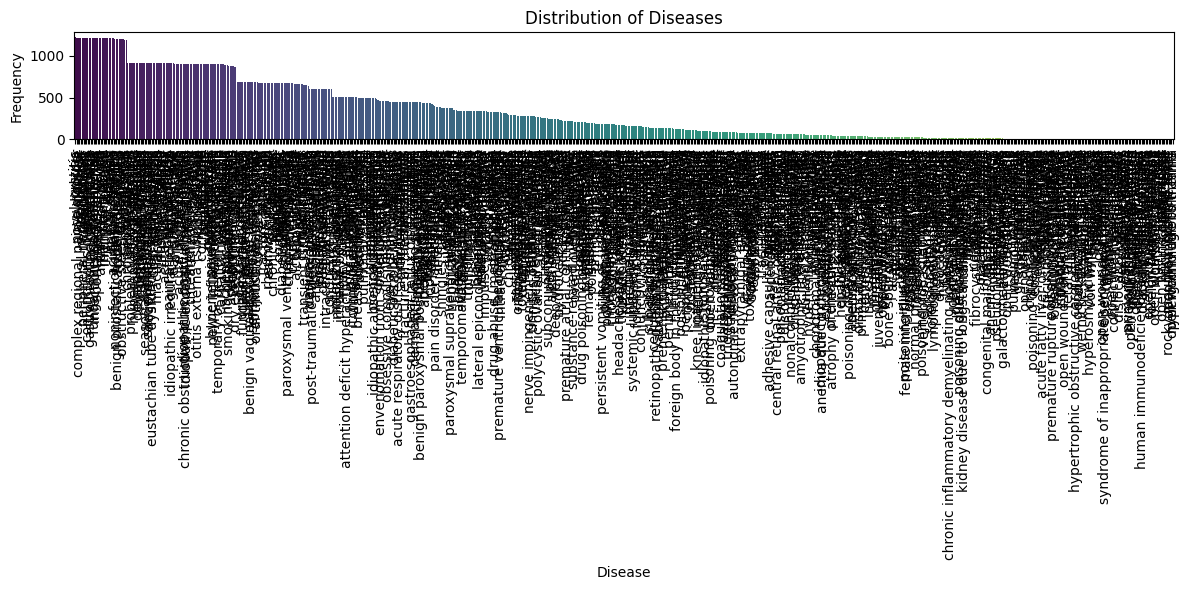

In [67]:
# 1. Disease Frequency Bar Chart
plt.figure(figsize=(12, 6))
disease_counts = df['diseases'].value_counts()
sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Disease')
plt.ylabel('Frequency')
plt.title('Distribution of Diseases')
plt.tight_layout()
plt.show()

<ipython-input-72-2be7cd26b9b5>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_symptoms.values, y=top_10_symptoms.index, palette='magma')


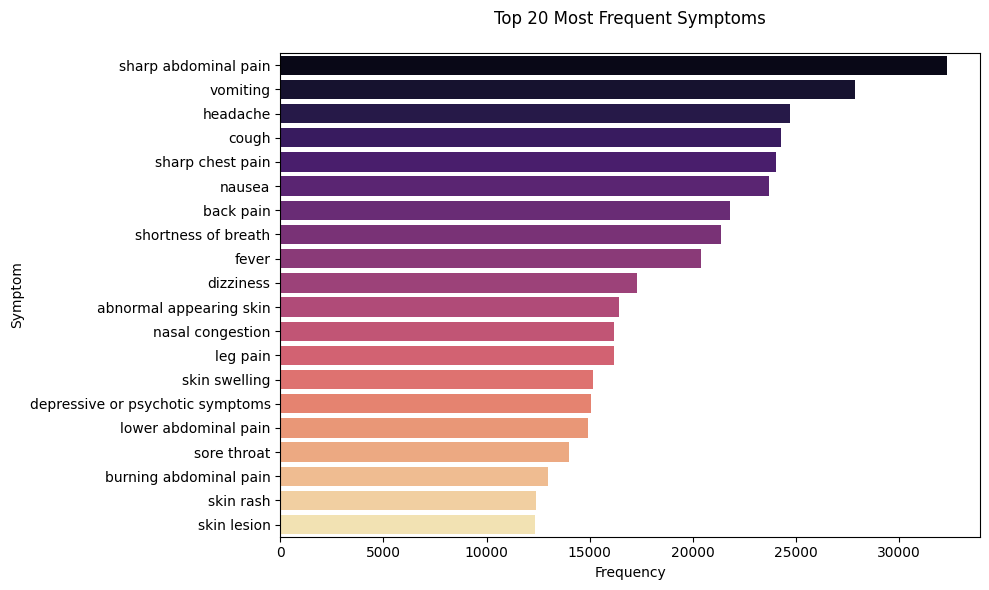

In [72]:
# 2. Top 20 Symptom Frequencies Horizontal Bar Chart
symptom_frequencies = df.drop('diseases', axis=1).sum().sort_values(ascending=False)
top_20_symptoms = symptom_frequencies.head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_symptoms.values, y=top_10_symptoms.index, palette='magma')
plt.xlabel('Frequency')
plt.ylabel('Symptom')
plt.title('Top 20 Most Frequent Symptoms\n')
plt.tight_layout()
plt.show()

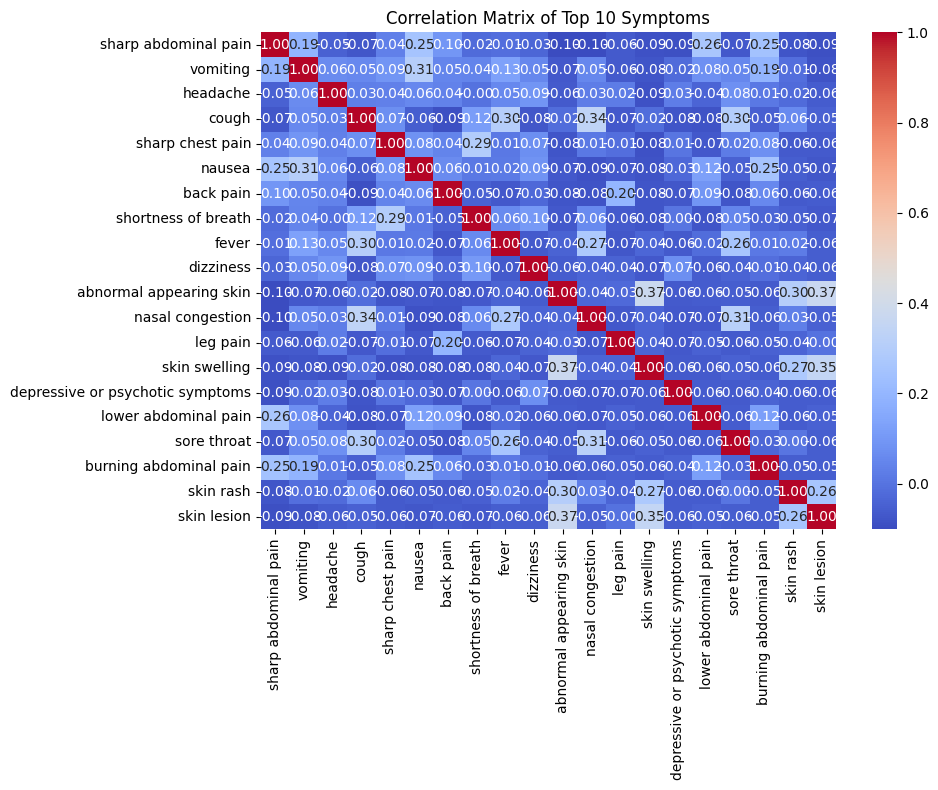

In [73]:
# 3. Heatmap of Top 20 Symptom Correlations
top_20_symptom_cols = top_20_symptoms.index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_20_symptom_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Top 10 Symptoms')
plt.tight_layout()
plt.show()

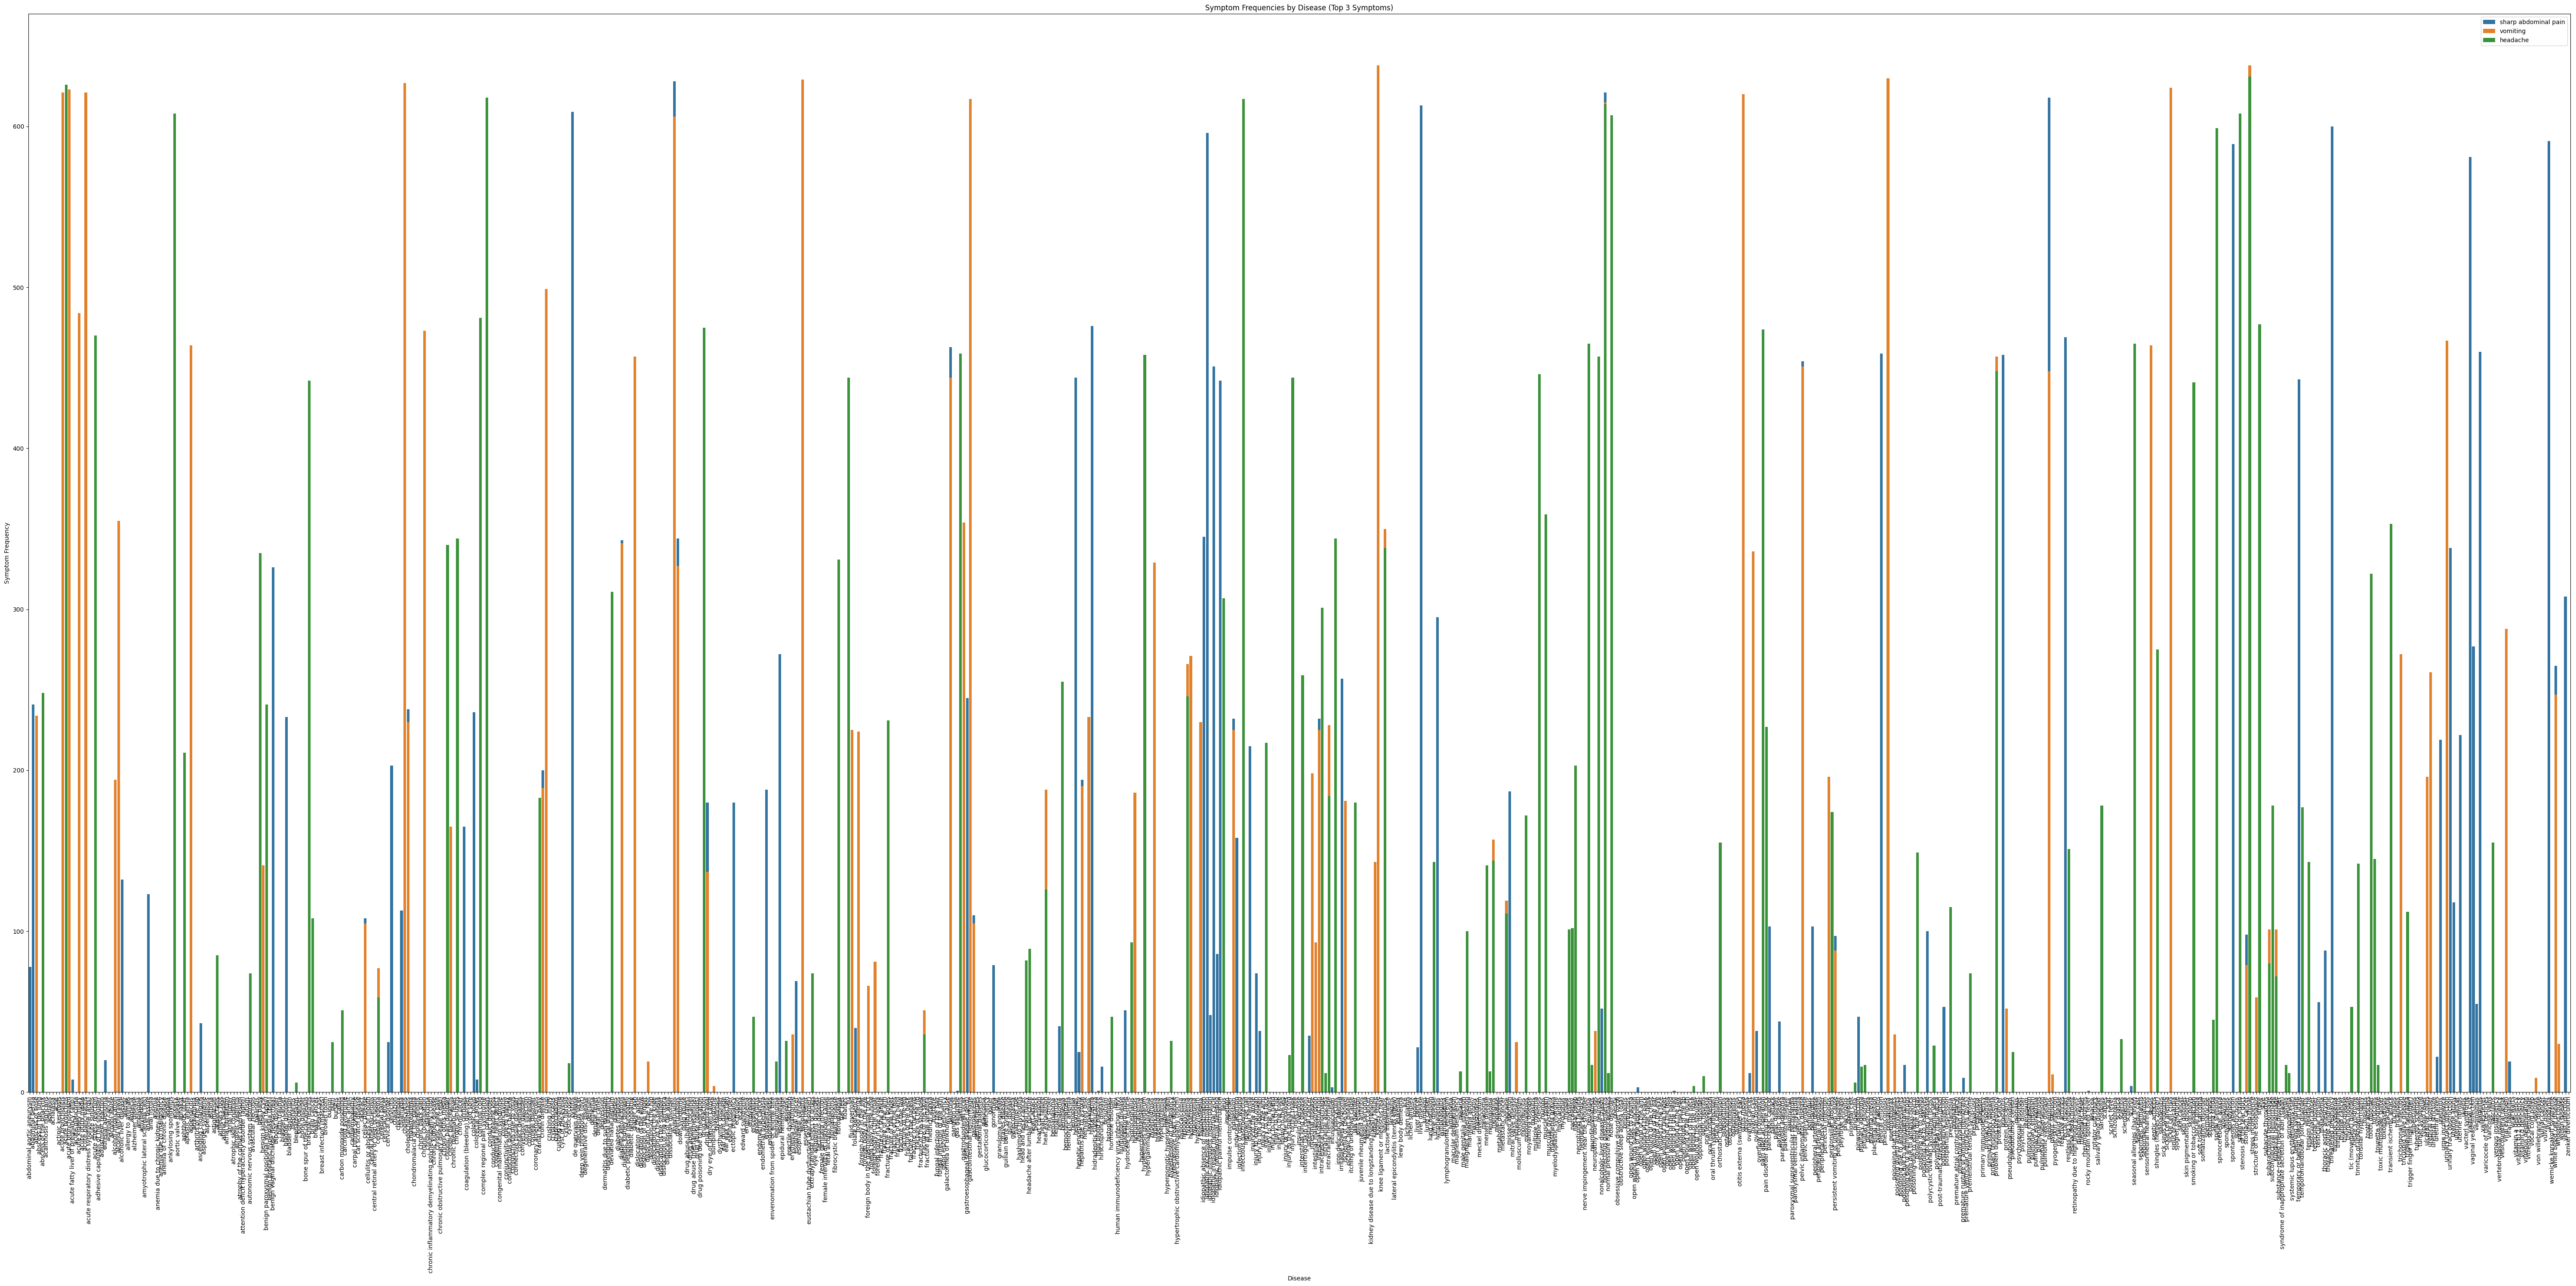

In [76]:
# 4.Grouped Bar Chart - Symptom Frequencies for each Disease (example for top 3 symptoms)
top_3_symptoms = symptom_frequencies.head(3).index
plt.figure(figsize=(60,30))
for symptom in top_3_symptoms:
    symptom_counts_by_disease = df.groupby('diseases')[symptom].sum()
    sns.barplot(x=symptom_counts_by_disease.index, y=symptom_counts_by_disease.values, label=symptom)
plt.xticks(rotation=90)
plt.xlabel('Disease')
plt.ylabel('Symptom Frequency')
plt.title('Symptom Frequencies by Disease (Top 3 Symptoms)')
plt.legend()
plt.tight_layout()
plt.show()